# RQ5 — Exit Strategy and Risk-Management Sensitivity

I compare hold-to-close with a pre-specified 50% stop-loss and 100% take-profit, then use other exit rules only as sensitivities.

In this notebook, I extend the original RQ5 buy-and-hold-to-close backtest.

The first RQ5 backtest deliberately used a simple rule:

- enter after the 15:00 ET signal;
- hold the selected 0DTE SPX option;
- exit near the close.

That provides a clean economic benchmark, but real traders often manage positions before the closing bell.

## Primary alternative exit policy

Before examining these results, I designate the following rule as the **primary risk-management alternative**:

> **Hard stop-loss at −50% of option premium and take-profit at +100%.**

In other words:

- if the option loses 50% of the executed entry premium, exit;
- if the option doubles in value, exit;
- if neither happens, exit near the end of the final hour.

This creates a nominal 2:1 reward-to-risk structure.

## Additional sensitivity policies

I also examine:

1. Hold to close — original RQ5 baseline.
2. −50% stop only.
3. +100% take-profit only.
4. −50% stop / +100% target — **primary alternative**.
5. −40% stop / +80% target.
6. −60% stop / +120% target.
7. Initial −50% stop, move stop to break-even after +50%.
8. Initial −50% stop, activate a 25% trailing stop after +50%.
9. Time exit around 15:30.
10. Time exit around 15:45.

These additional rules are **sensitivity analyses**, not a search for a new strategy to retrospectively declare optimal.

## Important one-minute-data limitation

The option data are one-minute OHLC aggregates. Within a minute we know the high and low, but not whether the high occurred before the low.

If both a stop and profit target are touched inside the same one-minute bar, the primary simulation uses the conservative assumption:

> **stop-loss occurred first.**

I count these ambiguous bars so I can report the limitation explicitly.

Historical NBBO quotes are unavailable under Options Starter, so the same synthetic adverse-execution assumptions from the original RQ5 backtest are retained.

In [ ]:
# I resolve the repository root before running any project-relative paths.
from pathlib import Path
import os

try:
    from dotenv import load_dotenv
except ModuleNotFoundError:
    # Path resolution still works before optional project dependencies are installed.
    def load_dotenv(*args, **kwargs):
        return False


def _find_project_root(start=None):
    location = Path(start or Path.cwd()).resolve()
    for candidate in (location, *location.parents):
        if (candidate / "config.yaml").is_file() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing config.yaml.")


PROJECT_ROOT = _find_project_root()
# The original notebooks were written from the repository root. Keeping that
# working directory preserves every existing data, output and model path.
os.chdir(PROJECT_ROOT)
load_dotenv(PROJECT_ROOT / "main.env")
print(f"Project root: {PROJECT_ROOT}")


## 1. Imports and configuration

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

# ------------------------------------------------------------
# Frozen signal settings
# ------------------------------------------------------------
PRIMARY_RQ1_COVERAGE = 0.30
PRIMARY_RQ2_MIN_BPS = 20.0

# ATM is still the main dissertation specification.
STRIKE_OFFSETS_POINTS = [0, 5, 10, 15, 20, 25, 30]
PRIMARY_STRIKE_OFFSET = 0

# ------------------------------------------------------------
# Entry and end-of-hour exit windows
# ------------------------------------------------------------
ENTRY_WINDOW_START = "15:00"
ENTRY_WINDOW_END = "15:05"

CLOSE_EXIT_WINDOW_START = "15:55"
CLOSE_EXIT_WINDOW_END = "15:59"

DEFAULT_CONTRACT_MULTIPLIER = 100.0

# ------------------------------------------------------------
# Execution scenarios: identical philosophy to original RQ5
# ------------------------------------------------------------
EXECUTION_SCENARIOS = {
    "frictionless": {
        "min_penalty_points": 0.00,
        "pct_of_reference_price": 0.000,
        "commission_per_side_usd": 0.00,
    },
    "low_cost": {
        "min_penalty_points": 0.05,
        "pct_of_reference_price": 0.020,
        "commission_per_side_usd": 1.00,
    },
    "medium_cost": {
        "min_penalty_points": 0.10,
        "pct_of_reference_price": 0.050,
        "commission_per_side_usd": 1.50,
    },
    "severe_cost": {
        "min_penalty_points": 0.20,
        "pct_of_reference_price": 0.100,
        "commission_per_side_usd": 2.00,
    },
}

PRIMARY_COST_SCENARIO = "medium_cost"

# Conservative rule when both stop and target occur within the same one-minute bar.
AMBIGUOUS_BAR_POLICY = "stop_first"

NEAR_TOTAL_LOSS_RETURN = -0.80

# Strategy definitions.
# pct values are expressed relative to executed entry premium:
# stop_pct=-0.50 => stop when option value is 50% below entry.
# target_pct=1.00 => take profit when option value is 100% above entry (doubles).
EXIT_POLICIES = {
    "hold_to_close": {
        "kind": "hold",
        "primary_alternative": False,
    },
    "stop50_only": {
        "kind": "stop_target",
        "stop_pct": -0.50,
        "target_pct": None,
        "primary_alternative": False,
    },
    "tp100_only": {
        "kind": "stop_target",
        "stop_pct": None,
        "target_pct": 1.00,
        "primary_alternative": False,
    },
    "stop50_tp100": {
        "kind": "stop_target",
        "stop_pct": -0.50,
        "target_pct": 1.00,
        "primary_alternative": True,
    },
    "stop40_tp80": {
        "kind": "stop_target",
        "stop_pct": -0.40,
        "target_pct": 0.80,
        "primary_alternative": False,
    },
    "stop60_tp120": {
        "kind": "stop_target",
        "stop_pct": -0.60,
        "target_pct": 1.20,
        "primary_alternative": False,
    },
    "breakeven_after_50": {
        "kind": "breakeven",
        "initial_stop_pct": -0.50,
        "activation_gain_pct": 0.50,
        "primary_alternative": False,
    },
    "trail25_after_50": {
        "kind": "trailing",
        "initial_stop_pct": -0.50,
        "activation_gain_pct": 0.50,
        "trail_pct": 0.25,
        "primary_alternative": False,
    },
    "time_exit_1530": {
        "kind": "time",
        "exit_time": "15:30",
        "primary_alternative": False,
    },
    "time_exit_1545": {
        "kind": "time",
        "exit_time": "15:45",
        "primary_alternative": False,
    },
}

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 280)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 2. Locate and load RQ5 retrieval outputs

In [2]:


PROJECT_ROOT = Path.cwd()

RQ5_ROOT = PROJECT_ROOT / "outputs" / "rq5_options_trading"
RAW_ROOT = RQ5_ROOT / "raw"
TABLE_ROOT = RQ5_ROOT / "tables"
FIGURE_ROOT = RQ5_ROOT / "figures"
EXIT_ROOT = RQ5_ROOT / "exit_strategy_sensitivity"

EXIT_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

BARS_PATH = RAW_ROOT / "rq5_option_minute_bars.parquet"
SELECTION_PATH = TABLE_ROOT / "rq5_contract_selection.csv"
CANDIDATES_PATH = TABLE_ROOT / "rq5_primary_candidate_sessions.csv"

required_paths = [BARS_PATH, SELECTION_PATH, CANDIDATES_PATH]
missing = [str(p) for p in required_paths if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Run notebooks/rq5_options_data_retrieval.ipynb first.\n"
        "Missing:\n- " + "\n- ".join(missing)
    )

bars = pd.read_parquet(BARS_PATH)
selection = pd.read_csv(SELECTION_PATH)
candidates = pd.read_csv(CANDIDATES_PATH)

bars["session_date"] = pd.to_datetime(bars["session_date"])
bars["timestamp"] = pd.to_datetime(bars["timestamp"])
selection["session_date"] = pd.to_datetime(selection["session_date"])
candidates["session_date"] = pd.to_datetime(candidates["session_date"])

# Same listed contract may appear more than once if multiple target offsets
# resolve to the same strike. Keep one raw bar per contract and timestamp.
bars_unique = (
    bars.sort_values(["session_date", "option_ticker", "timestamp"])
    .drop_duplicates(
        ["session_date", "option_ticker", "timestamp"],
        keep="first",
    )
    .reset_index(drop=True)
)

selection = selection[
    selection["selection_status"].eq("selected")
].copy()

selection["otm_offset_points"] = pd.to_numeric(
    selection["otm_offset_points"],
    errors="coerce",
)
selection["strike_price"] = pd.to_numeric(
    selection["strike_price"],
    errors="coerce",
)

print("Candidate dates:", len(candidates))
print("Selected contract mappings:", len(selection))
print("Unique option minute bars:", len(bars_unique))

Candidate dates: 20
Selected contract mappings: 280
Unique option minute bars: 15279


## 3. Reconstruct ML and mean-reversion direction

In [3]:
# I use this cell for reconstruct ml and mean-reversion direction.
candidates["rq1_high_confidence"] = (
    candidates["rq1_confidence_percentile"] > (1 - PRIMARY_RQ1_COVERAGE)
)

candidates["primary_candidate_check"] = (
    candidates["rq1_high_confidence"]
    & (candidates["rq2_predicted_move_bps"] >= PRIMARY_RQ2_MIN_BPS)
    & candidates["rq3_positive"].astype(bool)
)

if not candidates["primary_candidate_check"].all():
    raise ValueError(
        "Candidate file contains observations outside the frozen primary rule."
    )

candidates["ml_direction"] = np.where(
    candidates["rq1_prediction"].astype(int).eq(1),
    "call",
    "put",
)

candidates["mean_reversion_direction"] = np.where(
    candidates["ret_last_60m"] < 0,
    "call",
    "put",
)

display(
    candidates[
        [
            "session_date",
            "ml_direction",
            "mean_reversion_direction",
            "rq2_predicted_move_bps",
        ]
    ]
)

,session_date,ml_direction,mean_reversion_direction,rq2_predicted_move_bps
0,2024-12-20,call,put,23.505084
1,2025-01-02,call,put,20.517259
2,2025-01-14,call,call,22.377378
3,2025-04-02,call,call,26.982818
4,2025-04-11,call,call,36.368151
5,2025-04-14,call,put,26.306999
6,2025-04-17,call,call,31.334212
7,2025-05-07,call,put,22.278187
8,2025-11-06,put,put,20.014872
9,2025-11-20,put,put,28.797778


## 4. Price and execution helpers

In [4]:
def hhmm(ts):
    return pd.Timestamp(ts).strftime("%H:%M")


def penalty_points(reference_price, params):
    return max(
        float(params["min_penalty_points"]),
        float(params["pct_of_reference_price"]) * float(reference_price),
    )


def execute_buy(reference_price, params):
    penalty = penalty_points(reference_price, params)
    return float(reference_price) + penalty, penalty


def execute_sell(reference_price, params):
    reference_price = max(0.0, float(reference_price))
    penalty = penalty_points(reference_price, params)
    return max(0.0, reference_price - penalty), penalty


def get_entry_bar(contract_bars):
    contract_bars = contract_bars.sort_values("timestamp").copy()
    t = contract_bars["timestamp"].dt.strftime("%H:%M")

    eligible = contract_bars[
        (t >= ENTRY_WINDOW_START) & (t <= ENTRY_WINDOW_END)
    ]

    if eligible.empty:
        return None

    return eligible.iloc[0]


def get_close_exit_bar(contract_bars):
    contract_bars = contract_bars.sort_values("timestamp").copy()
    t = contract_bars["timestamp"].dt.strftime("%H:%M")

    eligible = contract_bars[
        (t >= CLOSE_EXIT_WINDOW_START)
        & (t <= CLOSE_EXIT_WINDOW_END)
    ]

    if eligible.empty:
        return None

    return eligible.iloc[-1]


def get_time_exit_bar(contract_bars, entry_timestamp, target_time):
    work = contract_bars[
        contract_bars["timestamp"] >= entry_timestamp
    ].sort_values("timestamp").copy()

    if work.empty:
        return None

    t = work["timestamp"].dt.strftime("%H:%M")

    # Prefer the last available bar at or before the requested time,
    # but no more than five minutes earlier.
    target_dt = pd.Timestamp(
        f"{pd.Timestamp(entry_timestamp).date()} {target_time}",
        tz=pd.Timestamp(entry_timestamp).tz,
    )
    lower_dt = target_dt - pd.Timedelta(minutes=5)

    eligible = work[
        (work["timestamp"] >= lower_dt)
        & (work["timestamp"] <= target_dt)
    ]

    if eligible.empty:
        return None

    return eligible.iloc[-1]

## 5. Path-dependent exit simulator

### Conservative gap handling

For a stop-loss:

- if the minute opens below the stop level, the reference exit is the lower bar open;
- otherwise the stop level is used.

For a take-profit:

- the target level is used as the reference fill even if the minute opens above it.

This keeps the simulation conservative.

### Break-even and trailing-stop timing

To avoid using the high and low of the same minute in an impossible sequence:

- break-even activation becomes effective from the **next** minute;
- a newly tightened trailing stop also becomes effective from the **next** minute.

This prevents intrabar look-ahead.

In [5]:
def simulate_exit(
    contract_bars,
    policy_name,
    policy,
    execution_params,
):
    contract_bars = contract_bars.sort_values("timestamp").copy()

    entry_bar = get_entry_bar(contract_bars)
    close_bar = get_close_exit_bar(contract_bars)

    if entry_bar is None or close_bar is None:
        return None

    entry_ref = float(entry_bar["open"])

    if not np.isfinite(entry_ref) or entry_ref <= 0:
        return None

    entry_exec, entry_penalty = execute_buy(
        entry_ref,
        execution_params,
    )

    entry_ts = pd.Timestamp(entry_bar["timestamp"])
    close_ts = pd.Timestamp(close_bar["timestamp"])

    # Bars available after the chosen entry and no later than the baseline close exit.
    path = contract_bars[
        (contract_bars["timestamp"] >= entry_ts)
        & (contract_bars["timestamp"] <= close_ts)
    ].sort_values("timestamp").copy()

    if path.empty:
        return None

    # Excursions measured from executed entry premium.
    max_high = pd.to_numeric(path["high"], errors="coerce").max()
    min_low = pd.to_numeric(path["low"], errors="coerce").min()

    mfe = (
        max_high / entry_exec - 1
        if np.isfinite(max_high)
        else np.nan
    )
    mae = (
        min_low / entry_exec - 1
        if np.isfinite(min_low)
        else np.nan
    )

    exit_reason = None
    exit_ts = None
    exit_ref = None
    ambiguous_bar = False

    kind = policy["kind"]

    # --------------------------------------------------------
    # Fixed time exits
    # --------------------------------------------------------
    if kind == "time":
        chosen = get_time_exit_bar(
            contract_bars,
            entry_ts,
            policy["exit_time"],
        )
        if chosen is None:
            return None

        exit_reason = f"time_{policy['exit_time']}"
        exit_ts = pd.Timestamp(chosen["timestamp"])
        exit_ref = float(chosen["close"])

    # --------------------------------------------------------
    # Pure hold baseline
    # --------------------------------------------------------
    elif kind == "hold":
        exit_reason = "close"
        exit_ts = close_ts
        exit_ref = float(close_bar["close"])

    # --------------------------------------------------------
    # Fixed stop / target
    # --------------------------------------------------------
    elif kind == "stop_target":
        stop_pct = policy.get("stop_pct")
        target_pct = policy.get("target_pct")

        stop_level = (
            entry_exec * (1 + stop_pct)
            if stop_pct is not None
            else None
        )
        target_level = (
            entry_exec * (1 + target_pct)
            if target_pct is not None
            else None
        )

        for bar in path.itertuples(index=False):
            bar_open = float(bar.open)
            bar_high = float(bar.high)
            bar_low = float(bar.low)

            stop_hit = (
                stop_level is not None
                and bar_low <= stop_level
            )
            target_hit = (
                target_level is not None
                and bar_high >= target_level
            )

            if stop_hit and target_hit:
                ambiguous_bar = True

                if AMBIGUOUS_BAR_POLICY == "stop_first":
                    exit_reason = "stop"
                    exit_ts = pd.Timestamp(bar.timestamp)
                    exit_ref = min(stop_level, bar_open)
                else:
                    exit_reason = "target"
                    exit_ts = pd.Timestamp(bar.timestamp)
                    exit_ref = target_level
                break

            if stop_hit:
                exit_reason = "stop"
                exit_ts = pd.Timestamp(bar.timestamp)
                exit_ref = min(stop_level, bar_open)
                break

            if target_hit:
                exit_reason = "target"
                exit_ts = pd.Timestamp(bar.timestamp)
                exit_ref = target_level
                break

        if exit_reason is None:
            exit_reason = "close"
            exit_ts = close_ts
            exit_ref = float(close_bar["close"])

    # --------------------------------------------------------
    # Break-even after +X%
    # --------------------------------------------------------
    elif kind == "breakeven":
        initial_stop = entry_exec * (
            1 + policy["initial_stop_pct"]
        )
        activation_level = entry_exec * (
            1 + policy["activation_gain_pct"]
        )

        active_stop = initial_stop
        breakeven_pending = False
        breakeven_active = False

        for bar in path.itertuples(index=False):
            if breakeven_pending:
                active_stop = max(active_stop, entry_exec)
                breakeven_active = True
                breakeven_pending = False

            bar_open = float(bar.open)
            bar_high = float(bar.high)
            bar_low = float(bar.low)

            if bar_low <= active_stop:
                exit_reason = (
                    "breakeven_stop"
                    if breakeven_active
                    else "initial_stop"
                )
                exit_ts = pd.Timestamp(bar.timestamp)
                exit_ref = min(active_stop, bar_open)
                break

            if (
                not breakeven_active
                and not breakeven_pending
                and bar_high >= activation_level
            ):
                # Effective from next minute only.
                breakeven_pending = True

        if exit_reason is None:
            exit_reason = "close"
            exit_ts = close_ts
            exit_ref = float(close_bar["close"])

    # --------------------------------------------------------
    # Trailing stop after +X%
    # --------------------------------------------------------
    elif kind == "trailing":
        active_stop = entry_exec * (
            1 + policy["initial_stop_pct"]
        )
        activation_level = entry_exec * (
            1 + policy["activation_gain_pct"]
        )
        trail_pct = policy["trail_pct"]

        trailing_active = False
        pending_trailing_stop = None
        running_high = entry_exec

        for bar in path.itertuples(index=False):
            if pending_trailing_stop is not None:
                active_stop = max(
                    active_stop,
                    pending_trailing_stop,
                )
                trailing_active = True
                pending_trailing_stop = None

            bar_open = float(bar.open)
            bar_high = float(bar.high)
            bar_low = float(bar.low)

            if bar_low <= active_stop:
                exit_reason = (
                    "trailing_stop"
                    if trailing_active
                    else "initial_stop"
                )
                exit_ts = pd.Timestamp(bar.timestamp)
                exit_ref = min(active_stop, bar_open)
                break

            running_high = max(running_high, bar_high)

            if (
                trailing_active
                or bar_high >= activation_level
            ):
                # Newly computed trail becomes active next minute.
                pending_trailing_stop = (
                    running_high * (1 - trail_pct)
                )

        if exit_reason is None:
            exit_reason = "close"
            exit_ts = close_ts
            exit_ref = float(close_bar["close"])

    else:
        raise ValueError(f"Unknown policy kind: {kind}")

    if (
        exit_ref is None
        or not np.isfinite(exit_ref)
        or exit_ref < 0
    ):
        return None

    exit_exec, exit_penalty = execute_sell(
        exit_ref,
        execution_params,
    )

    commission_side = float(
        execution_params["commission_per_side_usd"]
    )

    holding_minutes = (
        exit_ts - entry_ts
    ).total_seconds() / 60.0

    return {
        "policy": policy_name,
        "entry_timestamp": entry_ts,
        "exit_timestamp": exit_ts,
        "holding_minutes": holding_minutes,
        "entry_reference_price": entry_ref,
        "entry_execution_price": entry_exec,
        "entry_execution_penalty_points": entry_penalty,
        "exit_reference_price": exit_ref,
        "exit_execution_price": exit_exec,
        "exit_execution_penalty_points": exit_penalty,
        "exit_reason": exit_reason,
        "ambiguous_intrabar_stop_target": ambiguous_bar,
        "max_favorable_excursion": mfe,
        "max_adverse_excursion": mae,
        "commission_per_side_usd": commission_side,
        "total_commission_usd": 2 * commission_side,
    }

## 6. Build all strategy/strike/cost/policy simulations

In [6]:
# I use this cell for build all strategy/strike/cost/policy simulations.
candidate_signal_cols = [
    "session_date",
    "spx_at_1500",
    "rq1_confidence_percentile",
    "rq2_predicted_move_bps",
    "rq3_positive",
    "ml_direction",
    "mean_reversion_direction",
]

candidate_signals = candidates[
    candidate_signal_cols
].copy()

simulation_rows = []

for strategy, direction_col in [
    ("RQ1_ML", "ml_direction"),
    ("MeanReversion60m", "mean_reversion_direction"),
]:
    for candidate in candidate_signals.itertuples(index=False):
        required_type = getattr(candidate, direction_col)

        matching = selection[
            selection["session_date"].eq(
                pd.Timestamp(candidate.session_date)
            )
            & selection["option_type"].str.lower().eq(
                required_type
            )
            & selection["otm_offset_points"].isin(
                STRIKE_OFFSETS_POINTS
            )
        ].copy()

        for contract in matching.itertuples(index=False):
            contract_bars = bars_unique[
                bars_unique["session_date"].eq(
                    pd.Timestamp(candidate.session_date)
                )
                & bars_unique["option_ticker"].eq(
                    contract.ticker
                )
            ].copy()

            if contract_bars.empty:
                continue

            multiplier = pd.to_numeric(
                pd.Series(
                    [getattr(contract, "shares_per_contract", np.nan)]
                ),
                errors="coerce",
            ).iloc[0]

            fallback_multiplier = (
                not np.isfinite(multiplier)
                or multiplier <= 0
            )

            if fallback_multiplier:
                multiplier = DEFAULT_CONTRACT_MULTIPLIER

            for scenario_name, scenario_params in EXECUTION_SCENARIOS.items():
                for policy_name, policy in EXIT_POLICIES.items():
                    result = simulate_exit(
                        contract_bars,
                        policy_name,
                        policy,
                        scenario_params,
                    )

                    if result is None:
                        continue

                    capital_at_risk = (
                        result["entry_execution_price"] * multiplier
                        + result["commission_per_side_usd"]
                    )

                    pnl = (
                        (
                            result["exit_execution_price"]
                            - result["entry_execution_price"]
                        )
                        * multiplier
                        - result["total_commission_usd"]
                    )

                    return_on_premium = (
                        pnl / capital_at_risk
                        if capital_at_risk > 0
                        else np.nan
                    )

                    simulation_rows.append(
                        {
                            "session_date": pd.Timestamp(
                                candidate.session_date
                            ),
                            "strategy": strategy,
                            "required_option_type": required_type,
                            "option_ticker": contract.ticker,
                            "strike_price": contract.strike_price,
                            "otm_offset_points": contract.otm_offset_points,
                            "contract_multiplier": multiplier,
                            "multiplier_fallback_used": fallback_multiplier,
                            "execution_scenario": scenario_name,
                            "policy": policy_name,
                            "primary_alternative_policy": bool(
                                policy.get("primary_alternative", False)
                            ),
                            "rq1_confidence_percentile": (
                                candidate.rq1_confidence_percentile
                            ),
                            "rq2_predicted_move_bps": (
                                candidate.rq2_predicted_move_bps
                            ),
                            "rq3_positive": candidate.rq3_positive,
                            **result,
                            "capital_at_risk_usd": capital_at_risk,
                            "net_pnl_usd": pnl,
                            "net_return_on_premium": return_on_premium,
                            "winner": pnl > 0,
                            "near_total_loss": (
                                return_on_premium
                                <= NEAR_TOTAL_LOSS_RETURN
                            ),
                        }
                    )

simulations = pd.DataFrame(simulation_rows)

print("Simulation rows:", len(simulations))
print("Unique candidate dates:", simulations["session_date"].nunique())
print("Policies:", simulations["policy"].nunique())
print("Cost scenarios:", simulations["execution_scenario"].nunique())

display(simulations.head(30))

Simulation rows: 9520
Unique candidate dates: 17
Policies: 10
Cost scenarios: 4


,session_date,strategy,required_option_type,option_ticker,strike_price,otm_offset_points,contract_multiplier,multiplier_fallback_used,execution_scenario,policy,primary_alternative_policy,rq1_confidence_percentile,rq2_predicted_move_bps,rq3_positive,entry_timestamp,exit_timestamp,holding_minutes,entry_reference_price,entry_execution_price,entry_execution_penalty_points,exit_reference_price,exit_execution_price,exit_execution_penalty_points,exit_reason,ambiguous_intrabar_stop_target,max_favorable_excursion,max_adverse_excursion,commission_per_side_usd,total_commission_usd,capital_at_risk_usd,net_pnl_usd,net_return_on_premium,winner,near_total_loss
0,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,hold_to_close,False,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:59:00-05:00,59.000000,8.930000,8.930000,0.000000,22.900000,22.900000,0.000000,close,False,2.632699,-0.003359,0.000000,0.000000,893.000000,"1,397.000000",1.564390,True,False
1,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,stop50_only,False,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:59:00-05:00,59.000000,8.930000,8.930000,0.000000,22.900000,22.900000,0.000000,close,False,2.632699,-0.003359,0.000000,0.000000,893.000000,"1,397.000000",1.564390,True,False
2,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,tp100_only,False,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:04:00-05:00,4.000000,8.930000,8.930000,0.000000,17.860000,17.860000,0.000000,target,False,2.632699,-0.003359,0.000000,0.000000,893.000000,893.000000,1.000000,True,False
3,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,stop50_tp100,True,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:04:00-05:00,4.000000,8.930000,8.930000,0.000000,17.860000,17.860000,0.000000,target,False,2.632699,-0.003359,0.000000,0.000000,893.000000,893.000000,1.000000,True,False
4,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,stop40_tp80,False,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:04:00-05:00,4.000000,8.930000,8.930000,0.000000,16.074000,16.074000,0.000000,target,False,2.632699,-0.003359,0.000000,0.000000,893.000000,714.400000,0.800000,True,False
5,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,stop60_tp120,False,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:10:00-05:00,10.000000,8.930000,8.930000,0.000000,19.646000,19.646000,0.000000,target,False,2.632699,-0.003359,0.000000,0.000000,893.000000,"1,071.600000",1.200000,True,False
6,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,breakeven_after_50,False,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:59:00-05:00,59.000000,8.930000,8.930000,0.000000,22.900000,22.900000,0.000000,close,False,2.632699,-0.003359,0.000000,0.000000,893.000000,"1,397.000000",1.564390,True,False
7,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,trail25_after_50,False,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:15:00-05:00,15.000000,8.930000,8.930000,0.000000,19.590000,19.590000,0.000000,trailing_stop,False,2.632699,-0.003359,0.000000,0.000000,893.000000,"1,066.000000",1.193729,True,False
8,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,time_exit_1530,False,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:30:00-05:00,30.000000,8.930000,8.930000,0.000000,20.680000,20.680000,0.000000,time_15:30,False,2.632699,-0.003359,0.000000,0.000000,893.000000,"1,175.000000",1.315789,True,False
9,2025-01-02,RQ1_ML,call,O:SPXW250102C05845000,5845,0,100,False,frictionless,time_exit_1545,False,0.782178,20.517259,True,2025-01-02 15:00:00-05:00,2025-01-02 15:45:00-05:00,45.000000,8.930000,8.930000,0.000000,20.800000,20.800000,0.000000,time_15:45,False,2.632699,-0.003359,0.000000,0.000000,893.000000,"1,187.000000",1.329227,True,False

## 7. Verify the original hold-to-close result

In [7]:
# I use this cell for verify the original hold-to-close result.
baseline_check = simulations[
    simulations["policy"].eq("hold_to_close")
    & simulations["otm_offset_points"].eq(PRIMARY_STRIKE_OFFSET)
    & simulations["execution_scenario"].eq(PRIMARY_COST_SCENARIO)
].copy()

display(
    baseline_check.groupby("strategy").agg(
        trades=("session_date", "size"),
        total_pnl_usd=("net_pnl_usd", "sum"),
        mean_pnl_usd=("net_pnl_usd", "mean"),
        win_rate=("winner", "mean"),
        mean_return_on_premium=("net_return_on_premium", "mean"),
    )
)

print(
    "These values should closely match the primary ATM medium-cost results "
    "from rq5_options_backtest.ipynb."
)

,trades,total_pnl_usd,mean_pnl_usd,win_rate,mean_return_on_premium
strategy,,,,,
MeanReversion60m,17,"9,691.400000",570.082353,0.647059,0.559100
RQ1_ML,17,"9,551.000000",561.823529,0.647059,0.534846


These values should closely match the primary ATM medium-cost results from rq5_options_backtest.ipynb.


## 8. Performance helper functions

In [8]:
# I use this cell for performance helper functions.
def profit_factor(pnl):
    pnl = pd.to_numeric(pnl, errors="coerce").dropna()
    gains = pnl[pnl > 0].sum()
    losses = -pnl[pnl < 0].sum()

    if losses == 0:
        return np.inf if gains > 0 else np.nan

    return float(gains / losses)


def max_drawdown(frame):
    ordered = frame.sort_values("session_date")
    equity = ordered["net_pnl_usd"].cumsum()
    peak = equity.cummax()
    drawdown = equity - peak
    return float(drawdown.min()) if len(drawdown) else np.nan


def summarize(frame):
    if frame.empty:
        return {}

    return {
        "trades": len(frame),
        "win_rate": frame["winner"].mean(),
        "total_pnl_usd": frame["net_pnl_usd"].sum(),
        "mean_pnl_usd": frame["net_pnl_usd"].mean(),
        "median_pnl_usd": frame["net_pnl_usd"].median(),
        "mean_return_on_premium": (
            frame["net_return_on_premium"].mean()
        ),
        "median_return_on_premium": (
            frame["net_return_on_premium"].median()
        ),
        "profit_factor": profit_factor(
            frame["net_pnl_usd"]
        ),
        "max_drawdown_usd": max_drawdown(frame),
        "median_holding_minutes": (
            frame["holding_minutes"].median()
        ),
        "mean_holding_minutes": (
            frame["holding_minutes"].mean()
        ),
        "near_total_loss_rate": (
            frame["near_total_loss"].mean()
        ),
        "mean_mfe": (
            frame["max_favorable_excursion"].mean()
        ),
        "mean_mae": (
            frame["max_adverse_excursion"].mean()
        ),
        "ambiguous_bar_rate": (
            frame[
                "ambiguous_intrabar_stop_target"
            ].mean()
        ),
    }

## 9. Primary ATM medium-cost exit-policy comparison

I use this as the main table for this stage.

The principal comparison is:

> **hold to close vs −50% stop / +100% take-profit**

The other rows are sensitivity evidence.

In [9]:
# I use this cell for primary atm medium-cost exit-policy comparison.
primary_subset = simulations[
    simulations["otm_offset_points"].eq(PRIMARY_STRIKE_OFFSET)
    & simulations["execution_scenario"].eq(PRIMARY_COST_SCENARIO)
].copy()

rows = []

for keys, subset in primary_subset.groupby(
    ["strategy", "policy"],
    dropna=False,
):
    strategy, policy = keys
    rows.append(
        {
            "strategy": strategy,
            "policy": policy,
            "primary_alternative": (
                policy == "stop50_tp100"
            ),
            **summarize(subset),
        }
    )

primary_policy_summary = pd.DataFrame(rows).sort_values(
    ["strategy", "policy"]
)

display(primary_policy_summary)

primary_path = (
    TABLE_ROOT / "rq5_exit_policy_primary_atm_medium_cost.csv"
)
primary_policy_summary.to_csv(primary_path, index=False)
print("Saved:", primary_path)

,strategy,policy,primary_alternative,trades,win_rate,total_pnl_usd,mean_pnl_usd,median_pnl_usd,mean_return_on_premium,median_return_on_premium,profit_factor,max_drawdown_usd,median_holding_minutes,mean_holding_minutes,near_total_loss_rate,mean_mfe,mean_mae,ambiguous_bar_rate
0,MeanReversion60m,breakeven_after_50,False,17,0.117647,697.346250,41.020368,-77.077500,0.012769,-0.054029,1.190438,"-2,218.391250",20.000000,22.647059,0.000000,1.566874,-0.599540,0.000000
1,MeanReversion60m,hold_to_close,False,17,0.647059,"9,691.400000",570.082353,253.000000,0.559100,0.500495,3.052828,"-1,604.000000",59.000000,58.941176,0.294118,1.566874,-0.599540,0.000000
2,MeanReversion60m,stop40_tp80,False,17,0.411765,"1,943.979000",114.351706,-314.535000,0.036050,-0.432488,1.518907,"-1,912.081500",12.000000,12.529412,0.000000,1.566874,-0.599540,0.000000
3,MeanReversion60m,stop50_only,False,17,0.352941,"6,380.911250",375.347721,-427.462500,0.323742,-0.527338,2.233220,"-2,540.751250",42.000000,34.647059,0.000000,1.566874,-0.599540,0.000000
4,MeanReversion60m,stop50_tp100,True,17,0.470588,"2,103.868750",123.756985,-355.800000,0.091930,-0.527287,1.504473,"-1,822.551250",21.000000,23.176471,0.000000,1.566874,-0.599540,0.000000
5,MeanReversion60m,stop60_tp120,False,17,0.529412,"4,092.014500",240.706735,123.500000,0.221220,0.062850,1.932893,"-1,178.470000",21.000000,26.235294,0.000000,1.566874,-0.599540,0.000000
6,MeanReversion60m,time_exit_1530,False,17,0.588235,"1,856.150000",109.185294,112.300000,0.067483,0.154683,1.463690,"-1,540.500000",30.000000,30.000000,0.235294,1.566874,-0.599540,0.000000
7,MeanReversion60m,time_exit_1545,False,17,0.470588,"4,570.950000",268.879412,-91.500000,0.236741,-0.110108,1.768964,"-1,943.700000",45.000000,45.000000,0.294118,1.566874,-0.599540,0.000000
8,MeanReversion60m,tp100_only,False,17,0.764706,"6,922.340000",407.196471,658.500000,0.387400,0.894094,3.112079,-906.000000,51.000000,43.764706,0.235294,1.566874,-0.599540,0.000000
9,MeanReversion60m,trail25_after_50,False,17,0.588235,340.811250,20.047721,93.750000,-0.033265,0.112816,1.106245,"-1,160.876250",14.000000,14.764706,0.000000,1.566874,-0.599540,0.000000


Saved: c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\tables\rq5_exit_policy_primary_atm_medium_cost.csv


## 10. Exit-reason analysis

In [10]:
# I use this cell for exit-reason analysis.
exit_reason_summary = (
    primary_subset
    .groupby(
        ["strategy", "policy", "exit_reason"],
        dropna=False,
    )
    .agg(
        trades=("session_date", "size"),
        mean_pnl_usd=("net_pnl_usd", "mean"),
        median_pnl_usd=("net_pnl_usd", "median"),
        mean_return_on_premium=(
            "net_return_on_premium",
            "mean",
        ),
    )
    .reset_index()
)

totals = (
    exit_reason_summary
    .groupby(["strategy", "policy"])["trades"]
    .transform("sum")
)

exit_reason_summary["share_of_policy_trades"] = (
    exit_reason_summary["trades"] / totals
)

display(exit_reason_summary)

exit_reason_path = (
    TABLE_ROOT / "rq5_exit_reason_summary.csv"
)
exit_reason_summary.to_csv(exit_reason_path, index=False)
print("Saved:", exit_reason_path)

,strategy,policy,exit_reason,trades,mean_pnl_usd,median_pnl_usd,mean_return_on_premium,share_of_policy_trades
0,MeanReversion60m,breakeven_after_50,breakeven_stop,8,-56.753437,-47.887500,-0.053235,0.470588
1,MeanReversion60m,breakeven_after_50,close,2,"2,179.575000","2,179.575000",2.168006,0.117647
2,MeanReversion60m,breakeven_after_50,initial_stop,7,-458.253750,-477.075000,-0.527579,0.411765
3,MeanReversion60m,hold_to_close,close,17,570.082353,253.000000,0.559100,1.000000
4,MeanReversion60m,stop40_tp80,stop,10,-374.629650,-386.775000,-0.432761,0.588235
5,MeanReversion60m,stop40_tp80,target,7,812.896500,705.225000,0.705779,0.411765
6,MeanReversion60m,stop50_only,close,6,"1,925.850000","1,728.500000",1.887408,0.352941
7,MeanReversion60m,stop50_only,stop,11,-470.380795,-477.075000,-0.529166,0.647059
8,MeanReversion60m,stop50_tp100,close,1,123.500000,123.500000,0.062850,0.058824
9,MeanReversion60m,stop50_tp100,stop,9,-463.380694,-477.075000,-0.529430,0.529412


Saved: c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\tables\rq5_exit_reason_summary.csv


## 11. Stop-loss / take-profit trigger diagnostics

Maximum favourable excursion (MFE) asks:

> How far did the option rise above entry at its best point?

Maximum adverse excursion (MAE) asks:

> How far did the option fall below entry at its worst point?

These diagnostics help explain *why* a −50% / +100% rule succeeds or fails without changing the rule after the fact.

In [11]:
# I use this cell for stop-loss / take-profit trigger diagnostics.
path_diagnostics = (
    primary_subset[
        primary_subset["policy"].eq("hold_to_close")
    ]
    .groupby("strategy")
    .agg(
        trades=("session_date", "size"),
        median_mfe=("max_favorable_excursion", "median"),
        mean_mfe=("max_favorable_excursion", "mean"),
        share_ever_reached_plus_50=(
            "max_favorable_excursion",
            lambda x: float((x >= 0.50).mean()),
        ),
        share_ever_reached_plus_100=(
            "max_favorable_excursion",
            lambda x: float((x >= 1.00).mean()),
        ),
        median_mae=("max_adverse_excursion", "median"),
        mean_mae=("max_adverse_excursion", "mean"),
        share_ever_fell_minus_30=(
            "max_adverse_excursion",
            lambda x: float((x <= -0.30).mean()),
        ),
        share_ever_fell_minus_50=(
            "max_adverse_excursion",
            lambda x: float((x <= -0.50).mean()),
        ),
    )
    .reset_index()
)

display(path_diagnostics)

path_diag_path = TABLE_ROOT / "rq5_option_path_diagnostics.csv"
path_diagnostics.to_csv(path_diag_path, index=False)
print("Saved:", path_diag_path)

,strategy,trades,median_mfe,mean_mfe,share_ever_reached_plus_50,share_ever_reached_plus_100,median_mae,mean_mae,share_ever_fell_minus_30,share_ever_fell_minus_50
0,MeanReversion60m,17,1.332975,1.566874,0.764706,0.647059,-0.658385,-0.599540,0.764706,0.647059
1,RQ1_ML,17,1.247417,1.600248,0.764706,0.588235,-0.658385,-0.567486,0.705882,0.529412


Saved: c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\tables\rq5_option_path_diagnostics.csv


## 12. Paired comparison against hold-to-close

In [12]:
# I use this cell for paired comparison against hold-to-close.
paired_rows = []

medium_atm = simulations[
    simulations["otm_offset_points"].eq(PRIMARY_STRIKE_OFFSET)
    & simulations["execution_scenario"].eq(PRIMARY_COST_SCENARIO)
].copy()

baseline = (
    medium_atm[
        medium_atm["policy"].eq("hold_to_close")
    ][
        [
            "session_date",
            "strategy",
            "net_pnl_usd",
            "net_return_on_premium",
        ]
    ]
    .rename(
        columns={
            "net_pnl_usd": "baseline_pnl_usd",
            "net_return_on_premium": "baseline_return",
        }
    )
)

for policy in EXIT_POLICIES:
    if policy == "hold_to_close":
        continue

    alt = medium_atm[
        medium_atm["policy"].eq(policy)
    ][
        [
            "session_date",
            "strategy",
            "net_pnl_usd",
            "net_return_on_premium",
        ]
    ].copy()

    paired = alt.merge(
        baseline,
        on=["session_date", "strategy"],
        how="inner",
        validate="one_to_one",
    )

    paired["pnl_difference_usd"] = (
        paired["net_pnl_usd"]
        - paired["baseline_pnl_usd"]
    )

    for strategy, subset in paired.groupby("strategy"):
        paired_rows.append(
            {
                "strategy": strategy,
                "policy": policy,
                "paired_trades": len(subset),
                "mean_pnl_difference_vs_hold_usd": (
                    subset["pnl_difference_usd"].mean()
                ),
                "median_pnl_difference_vs_hold_usd": (
                    subset["pnl_difference_usd"].median()
                ),
                "share_policy_beats_hold": (
                    subset["pnl_difference_usd"] > 0
                ).mean(),
            }
        )

paired_policy_comparison = pd.DataFrame(paired_rows)

display(paired_policy_comparison)

paired_path = (
    TABLE_ROOT / "rq5_exit_policy_paired_vs_hold.csv"
)
paired_policy_comparison.to_csv(paired_path, index=False)
print("Saved:", paired_path)

,strategy,policy,paired_trades,mean_pnl_difference_vs_hold_usd,median_pnl_difference_vs_hold_usd,share_policy_beats_hold
0,MeanReversion60m,stop50_only,17,-194.734632,0.000000,0.294118
1,RQ1_ML,stop50_only,17,-60.101471,0.000000,0.352941
2,MeanReversion60m,tp100_only,17,-162.885882,0.000000,0.235294
3,RQ1_ML,tp100_only,17,-257.505882,0.000000,0.176471
4,MeanReversion60m,stop50_tp100,17,-446.325368,-408.500000,0.352941
5,RQ1_ML,stop50_tp100,17,-383.840515,-313.500000,0.411765
6,MeanReversion60m,stop40_tp80,17,-455.730647,-315.685000,0.411765
7,RQ1_ML,stop40_tp80,17,-405.054294,-298.490000,0.470588
8,MeanReversion60m,stop60_tp120,17,-329.375618,-173.850000,0.411765
9,RQ1_ML,stop60_tp120,17,-376.254029,-173.850000,0.294118


Saved: c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\tables\rq5_exit_policy_paired_vs_hold.csv


## 13. Strike-distance sensitivity for exit policies

In [13]:
# I use this cell for strike-distance sensitivity for exit policies.
strike_rows = []

medium = simulations[
    simulations["execution_scenario"].eq(
        PRIMARY_COST_SCENARIO
    )
].copy()

for keys, subset in medium.groupby(
    ["strategy", "policy", "otm_offset_points"],
    dropna=False,
):
    strategy, policy, offset = keys

    strike_rows.append(
        {
            "strategy": strategy,
            "policy": policy,
            "otm_offset_points": offset,
            **summarize(subset),
        }
    )

strike_policy_summary = pd.DataFrame(strike_rows)

display(strike_policy_summary)

strike_path = (
    TABLE_ROOT / "rq5_exit_policy_strike_sensitivity.csv"
)
strike_policy_summary.to_csv(strike_path, index=False)
print("Saved:", strike_path)

,strategy,policy,otm_offset_points,trades,win_rate,total_pnl_usd,mean_pnl_usd,median_pnl_usd,mean_return_on_premium,median_return_on_premium,profit_factor,max_drawdown_usd,median_holding_minutes,mean_holding_minutes,near_total_loss_rate,mean_mfe,mean_mae,ambiguous_bar_rate
0,MeanReversion60m,breakeven_after_50,0,17,0.117647,697.346250,41.020368,-77.077500,0.012769,-0.054029,1.190438,"-2,218.391250",20.000000,22.647059,0.000000,1.566874,-0.599540,0.000000
1,MeanReversion60m,breakeven_after_50,5,17,0.117647,391.662500,23.038971,-87.525000,-0.021822,-0.059242,1.133763,"-1,878.847500",12.000000,21.000000,0.000000,1.815630,-0.653836,0.000000
2,MeanReversion60m,breakeven_after_50,10,17,0.058824,"-1,406.743750",-82.749632,-73.875000,-0.207786,-0.066158,0.341210,"-1,626.806250",11.000000,18.117647,0.000000,2.026333,-0.719338,0.000000
3,MeanReversion60m,breakeven_after_50,15,17,0.000000,"-1,721.360000",-101.256471,-86.500000,-0.305618,-0.350917,0.000000,"-1,550.860000",10.000000,14.529412,0.000000,2.174418,-0.773033,0.000000
4,MeanReversion60m,breakeven_after_50,20,17,0.000000,"-1,163.002500",-68.411912,-54.450000,-0.322088,-0.382796,0.000000,"-1,042.377500",10.000000,16.000000,0.000000,2.224694,-0.841686,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,RQ1_ML,trail25_after_50,10,17,0.529412,205.612500,12.094853,56.625000,-0.037799,0.103425,1.100164,-871.312500,8.000000,10.058824,0.000000,2.171478,-0.656151,0.000000
136,RQ1_ML,trail25_after_50,15,17,0.529412,191.812500,11.283088,44.212500,-0.036535,0.119139,1.132281,-629.112500,5.000000,7.705882,0.000000,2.438197,-0.720113,0.000000
137,RQ1_ML,trail25_after_50,20,17,0.529412,581.762500,34.221324,21.375000,-0.013789,0.079387,1.584224,-383.162500,5.000000,6.647059,0.058824,2.627911,-0.827584,0.000000
138,RQ1_ML,trail25_after_50,25,17,0.411765,17.512500,1.030147,-60.500000,-0.146871,-0.550412,1.017232,-640.250000,5.000000,6.352941,0.058824,2.805715,-0.865866,0.000000


Saved: c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\tables\rq5_exit_policy_strike_sensitivity.csv


## 14. Transaction-cost sensitivity for the −50% / +100% policy

In [14]:
# I use this cell for transaction-cost sensitivity for the −50% / +100% policy.
stop_target_cost = simulations[
    simulations["policy"].eq("stop50_tp100")
    & simulations["otm_offset_points"].eq(
        PRIMARY_STRIKE_OFFSET
    )
].copy()

cost_rows = []

for keys, subset in stop_target_cost.groupby(
    ["strategy", "execution_scenario"],
    dropna=False,
):
    strategy, scenario = keys

    cost_rows.append(
        {
            "strategy": strategy,
            "execution_scenario": scenario,
            **summarize(subset),
        }
    )

stop_target_cost_summary = pd.DataFrame(cost_rows)

display(stop_target_cost_summary)

cost_path = (
    TABLE_ROOT / "rq5_stop50_tp100_cost_sensitivity.csv"
)
stop_target_cost_summary.to_csv(cost_path, index=False)
print("Saved:", cost_path)

,strategy,execution_scenario,trades,win_rate,total_pnl_usd,mean_pnl_usd,median_pnl_usd,mean_return_on_premium,median_return_on_premium,profit_factor,max_drawdown_usd,median_holding_minutes,mean_holding_minutes,near_total_loss_rate,mean_mfe,mean_mae,ambiguous_bar_rate
0,MeanReversion60m,frictionless,17,0.529412,"5,840.500000",343.558824,480.000000,0.294118,1.000000,2.743173,-900.500000,19.000000,20.000000,0.000000,1.695218,-0.579517,0.000000
1,MeanReversion60m,low_cost,17,0.470588,"2,710.095000",159.417353,-334.928000,0.130299,-0.511586,1.691764,"-1,662.560200",19.000000,21.647059,0.000000,1.642370,-0.587761,0.000000
2,MeanReversion60m,medium_cost,17,0.470588,"2,103.868750",123.756985,-355.800000,0.091930,-0.527287,1.504473,"-1,822.551250",21.000000,23.176471,0.000000,1.566874,-0.599540,0.000000
3,MeanReversion60m,severe_cost,17,0.411765,"1,070.225000",62.954412,-391.200000,0.031688,-0.552860,1.230203,"-2,064.555000",21.000000,23.411765,0.000000,1.450198,-0.617742,0.000000
4,RQ1_ML,frictionless,17,0.529412,"5,591.500000",328.911765,690.000000,0.294118,1.000000,2.554274,"-1,277.500000",17.000000,17.470588,0.000000,1.730260,-0.545861,0.000000
5,RQ1_ML,low_cost,17,0.529412,"3,638.319800",214.018812,246.600000,0.216955,0.129218,1.967884,"-1,387.829000",17.000000,20.235294,0.000000,1.676725,-0.554765,0.000000
6,RQ1_ML,medium_cost,17,0.529412,"3,025.711250",177.983015,123.500000,0.176752,0.062850,1.758277,"-1,546.143750",17.000000,21.764706,0.000000,1.600248,-0.567486,0.000000
7,RQ1_ML,severe_cost,17,0.470588,"1,942.745000",114.279118,-81.000000,0.111111,-0.039339,1.435010,"-1,820.575000",21.000000,22.764706,0.000000,1.482055,-0.587146,0.000000


Saved: c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\tables\rq5_stop50_tp100_cost_sensitivity.csv


## 15. Cumulative P&L: hold-to-close versus −50% / +100%

Saved: c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\figures\rq5_hold_vs_stop50_tp100.png


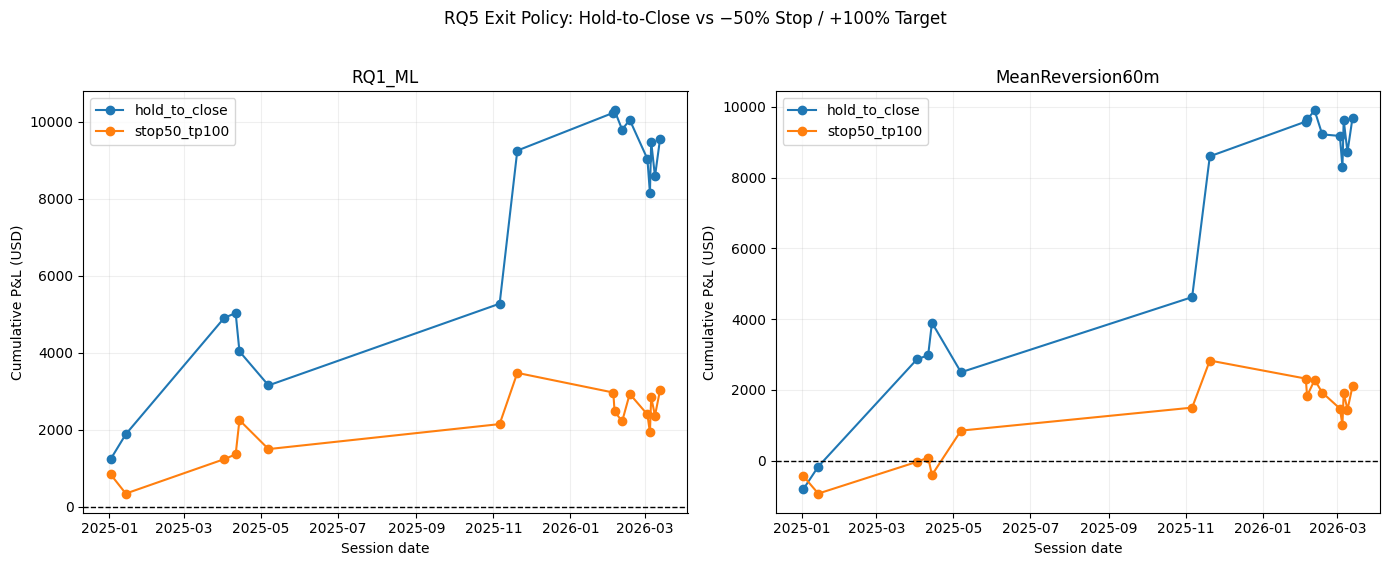

In [15]:
# I use this cell for cumulative p&l: hold-to-close versus −50% / +100%.
plot_data = primary_subset[
    primary_subset["policy"].isin(
        ["hold_to_close", "stop50_tp100"]
    )
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, strategy in zip(
    axes,
    ["RQ1_ML", "MeanReversion60m"],
):
    subset = plot_data[
        plot_data["strategy"].eq(strategy)
    ]

    for policy, policy_frame in subset.groupby("policy"):
        policy_frame = policy_frame.sort_values(
            "session_date"
        ).copy()

        policy_frame["cumulative_pnl_usd"] = (
            policy_frame["net_pnl_usd"].cumsum()
        )

        ax.plot(
            policy_frame["session_date"],
            policy_frame["cumulative_pnl_usd"],
            marker="o",
            label=policy,
        )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1,
    )
    ax.set_title(strategy)
    ax.set_xlabel("Session date")
    ax.set_ylabel("Cumulative P&L (USD)")
    ax.legend()
    ax.grid(alpha=0.2)

fig.suptitle(
    "RQ5 Exit Policy: Hold-to-Close vs −50% Stop / +100% Target",
    y=1.02,
)
fig.tight_layout()

fig_path = (
    FIGURE_ROOT / "rq5_hold_vs_stop50_tp100.png"
)
fig.savefig(fig_path, dpi=220, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 16. Risk/return comparison chart for all ATM policies

Saved: c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\figures\rq5_exit_policy_risk_return.png


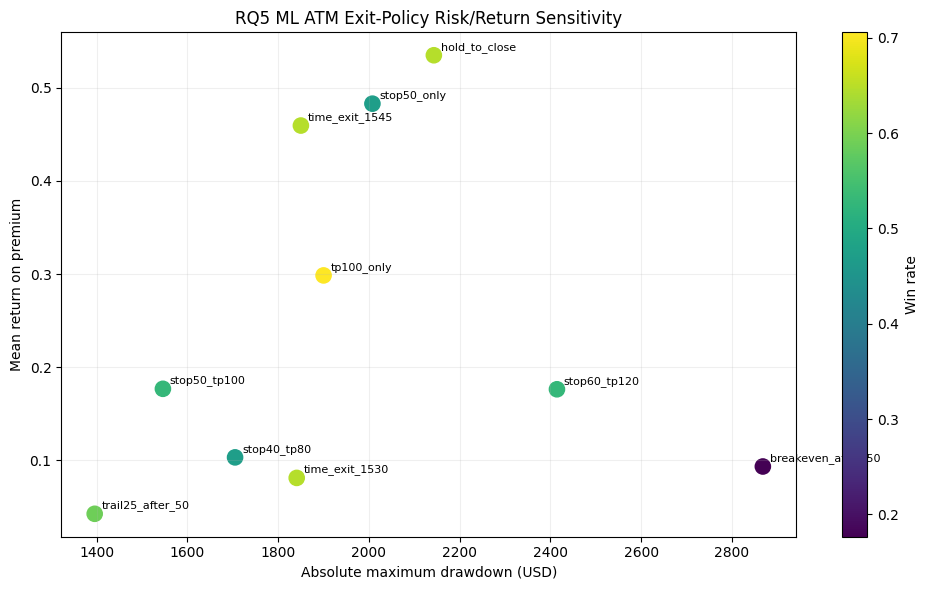

In [16]:
# I use this cell for risk/return comparison chart for all atm policies.
chart = primary_policy_summary[
    primary_policy_summary["strategy"].eq("RQ1_ML")
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    chart["max_drawdown_usd"].abs(),
    chart["mean_return_on_premium"],
    s=120,
    c=chart["win_rate"],
    cmap="viridis",
)

for row in chart.itertuples(index=False):
    ax.annotate(
        row.policy,
        (
            abs(row.max_drawdown_usd),
            row.mean_return_on_premium,
        ),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Absolute maximum drawdown (USD)")
ax.set_ylabel("Mean return on premium")
ax.set_title(
    "RQ5 ML ATM Exit-Policy Risk/Return Sensitivity"
)
ax.grid(alpha=0.2)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Win rate")

fig.tight_layout()
risk_path = FIGURE_ROOT / "rq5_exit_policy_risk_return.png"
fig.savefig(risk_path, dpi=220, bbox_inches="tight")
print("Saved:", risk_path)
plt.show()

## 17. Small-sample warning and interpretation rules

There are only a small number of primary candidate trades. Testing many exit rules on the same historical trades creates a serious risk of **strategy-selection overfitting**.

Therefore:

- the original hold-to-close strategy remains the baseline;
- −50% stop / +100% take-profit is the **pre-specified primary alternative**;
- all other policies are sensitivity analyses;
- do not select whichever policy has the largest historical P&L and call it the final strategy;
- any policy intended for future use should be frozen before the fresh holdout is evaluated.

The key question is not:

> Which of ten policies happened to make the most money?

It is:

> Does adding a reasonable, pre-specified risk-management rule materially improve the return/drawdown characteristics of the original strategy?

## 18. Conservative interpretation generator

In [17]:
def summary_row(strategy, policy):
    row = primary_policy_summary[
        primary_policy_summary["strategy"].eq(strategy)
        & primary_policy_summary["policy"].eq(policy)
    ]
    if len(row) != 1:
        return None
    return row.iloc[0]


ml_hold = summary_row("RQ1_ML", "hold_to_close")
ml_stop_target = summary_row("RQ1_ML", "stop50_tp100")
mr_hold = summary_row("MeanReversion60m", "hold_to_close")
mr_stop_target = summary_row("MeanReversion60m", "stop50_tp100")

if ml_hold is None or ml_stop_target is None:
    raise ValueError("Primary ML exit-policy results are unavailable.")

pnl_change = (
    ml_stop_target["total_pnl_usd"]
    - ml_hold["total_pnl_usd"]
)

drawdown_change = (
    abs(ml_stop_target["max_drawdown_usd"])
    - abs(ml_hold["max_drawdown_usd"])
)

if pnl_change > 0:
    pnl_clause = (
        f"Using the −50% stop / +100% take-profit rule increased "
        f"historical total P&L by ${pnl_change:.2f} relative to holding "
        "the ATM option until the end-of-hour exit."
    )
else:
    pnl_clause = (
        f"Using the −50% stop / +100% take-profit rule reduced "
        f"historical total P&L by ${abs(pnl_change):.2f} relative to "
        "holding the ATM option until the end-of-hour exit."
    )

if drawdown_change < 0:
    dd_clause = (
        f"However, absolute maximum drawdown improved by "
        f"${abs(drawdown_change):.2f}."
    )
elif drawdown_change > 0:
    dd_clause = (
        f"Absolute maximum drawdown worsened by "
        f"${drawdown_change:.2f}."
    )
else:
    dd_clause = (
        "Maximum drawdown was unchanged."
    )

ambiguous_count = int(
    primary_subset[
        primary_subset["policy"].eq("stop50_tp100")
    ]["ambiguous_intrabar_stop_target"].sum()
)

draft = f"""
### RQ5 Exit-Strategy Sensitivity

The original RQ5 analysis used a simple hold-to-close exit so that the
economic value of the predictive signal could be evaluated without introducing
additional trading-rule complexity. A second analysis therefore examined
whether an explicit retail-style risk-management policy changed the results.

The primary alternative used a hard stop-loss at 50% below the executed
option premium and a take-profit at 100% above entry. If neither threshold was
reached, the position was closed near the end of the final trading hour.

For the ML ATM strategy under the medium-cost execution assumptions,
holding to close generated total P&L of
${ml_hold['total_pnl_usd']:.2f}, whereas the −50%/+100% policy generated
${ml_stop_target['total_pnl_usd']:.2f}. {pnl_clause} {dd_clause}
The stop/target strategy produced a win rate of
{ml_stop_target['win_rate']:.1%}, mean return on premium of
{ml_stop_target['mean_return_on_premium']:.1%}, and median holding time of
{ml_stop_target['median_holding_minutes']:.1f} minutes.

Because one-minute option aggregates do not reveal whether the high or low
occurred first within a minute, a conservative stop-first assumption was used
when both thresholds were touched in the same bar. There were
{ambiguous_count} such ambiguous simulated observations across the primary
comparison table.

The additional stop, target, break-even, trailing-stop and fixed-time exit
rules should be interpreted as sensitivity analyses rather than as independent
strategies selected after observing historical profitability. Given the small
number of trade opportunities, the purpose of this analysis is to determine
whether reasonable risk management materially changes the original RQ5
conclusion, not to optimise an exit rule on the development sample.
"""

print(draft)

draft_path = EXIT_ROOT / "rq5_exit_strategy_draft.md"
draft_path.write_text(draft, encoding="utf-8")
print("Saved:", draft_path)


### RQ5 Exit-Strategy Sensitivity

The original RQ5 analysis used a simple hold-to-close exit so that the
economic value of the predictive signal could be evaluated without introducing
additional trading-rule complexity. A second analysis therefore examined
whether an explicit retail-style risk-management policy changed the results.

The primary alternative used a hard stop-loss at 50% below the executed
option premium and a take-profit at 100% above entry. If neither threshold was
reached, the position was closed near the end of the final trading hour.

For the ML ATM strategy under the medium-cost execution assumptions,
holding to close generated total P&L of
$9551.00, whereas the −50%/+100% policy generated
$3025.71. Using the −50% stop / +100% take-profit rule reduced historical total P&L by $6525.29 relative to holding the ATM option until the end-of-hour exit. However, absolute maximum drawdown improved by $597.06.
The stop/target strategy produced a win rate of
52.9%, mean retu

## 19. Save complete simulation log and manifest

In [ ]:
# I use this cell for save complete simulation log and manifest.
simulation_path = (
    EXIT_ROOT / "rq5_exit_strategy_simulations.parquet"
)
simulation_csv_path = (
    EXIT_ROOT / "rq5_exit_strategy_simulations.csv"
)

simulations.to_parquet(simulation_path, index=False)
simulations.to_csv(simulation_csv_path, index=False)

manifest = {
    "research_question": "RQ5",
    "analysis": "exit_strategy_sensitivity",
    "fresh_holdout_used": False,
    "primary_baseline": "hold_to_close",
    "primary_alternative": "stop50_tp100",
    "primary_strike_offset_points": PRIMARY_STRIKE_OFFSET,
    "primary_execution_scenario": PRIMARY_COST_SCENARIO,
    "ambiguous_intrabar_policy": AMBIGUOUS_BAR_POLICY,
    "entry_window_et": [
        ENTRY_WINDOW_START,
        ENTRY_WINDOW_END,
    ],
    "close_exit_window_et": [
        CLOSE_EXIT_WINDOW_START,
        CLOSE_EXIT_WINDOW_END,
    ],
    "exit_policies": EXIT_POLICIES,
    "execution_scenarios": EXECUTION_SCENARIOS,
    "methodology_notes": [
        "Stop and target percentages are based on executed entry premium.",
        "If both fixed stop and target are touched in the same one-minute bar, stop is assumed first.",
        "Break-even and newly tightened trailing stops become active on the next minute bar.",
        "Stop gaps use the lower of stop level and bar open as the reference exit.",
        "All policies except stop50_tp100 are sensitivity analyses.",
        "No historical NBBO quotes are available; execution penalties are synthetic sensitivity assumptions.",
    ],
}

manifest_path = EXIT_ROOT / "rq5_exit_strategy_manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2, default=str),
    encoding="utf-8",
)

print("Saved:")
print(" -", simulation_path)
print(" -", simulation_csv_path)
print(" -", manifest_path)

Saved:
 - c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\exit_strategy_sensitivity\rq5_exit_strategy_simulations.parquet
 - c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\exit_strategy_sensitivity\rq5_exit_strategy_simulations.csv
 - c:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\rq5_options_trading\exit_strategy_sensitivity\rq5_exit_strategy_manifest.json


: 

## 20. Most important outputs

After I run this notebook, I review these outputs first:

1. `rq5_exit_policy_primary_atm_medium_cost.csv`
   - main ATM comparison across exit policies.

2. `rq5_exit_policy_paired_vs_hold.csv`
   - asks whether each policy actually improved the **same individual trades** relative to holding until close.

3. `rq5_exit_reason_summary.csv`
   - shows how often the −50% stop, +100% target, break-even or trailing stop actually triggered.

4. `rq5_option_path_diagnostics.csv`
   - shows how often options reached +50%, +100%, −30% and −50% during the hour.

5. `rq5_exit_policy_strike_sensitivity.csv`
   - tests whether exit management behaves differently for ATM versus 5–30 point OTM contracts.

6. `rq5_stop50_tp100_cost_sensitivity.csv`
   - checks whether the primary alternative survives transaction-cost assumptions.

### Dissertation decision rule

Do not ask which rule has the maximum historical profit.

Instead compare:

**Hold-to-close baseline**  
versus  
**Pre-specified −50% stop / +100% take-profit**

on:

- total P&L;
- mean return on premium;
- maximum drawdown;
- near-total-loss rate;
- win rate;
- holding time;
- robustness to execution costs.

The other policies help explain sensitivity but should not become the final strategy solely because one happened to rank first on these 17 historical opportunities.